In [7]:
import librosa
import numpy as np
import shutil
from pathlib import Path
from pydub import AudioSegment

In [8]:
input_folder = Path("/home/cjk/Dev/04_Lewagon/cats/260908 CatSound_originals_only/CatSound_originals")
output_folder = Path("/home/cjk/Dev/cats")


Found 2953 files
Processed 50/2953
Processed 100/2953
Processed 150/2953
Processed 200/2953
Processed 250/2953
Processed 300/2953
Processed 350/2953
Processed 400/2953
Processed 450/2953
Processed 500/2953
Processed 550/2953
Processed 600/2953
Processed 650/2953
Processed 700/2953
Processed 750/2953


Note: Illegal Audio-MPEG-Header 0xbf082800 at offset 7536.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Processed 800/2953
Processed 850/2953
Processed 900/2953
Processed 950/2953
Processed 1000/2953
Processed 1050/2953
Processed 1100/2953
Processed 1150/2953
Processed 1200/2953
Processed 1250/2953
Processed 1300/2953
Processed 1350/2953
Processed 1400/2953
Processed 1450/2953
Processed 1500/2953
Processed 1550/2953
Processed 1600/2953
Processed 1650/2953
Processed 1700/2953
Processed 1750/2953
Processed 1800/2953
Processed 1850/2953
Processed 1900/2953
Processed 1950/2953
Processed 2000/2953
Processed 2050/2953
Processed 2100/2953
Processed 2150/2953
Processed 2200/2953
Processed 2250/2953
Processed 2300/2953
Processed 2350/2953
Processed 2400/2953
Processed 2450/2953
Processed 2500/2953
Processed 2550/2953
Processed 2600/2953
Processed 2650/2953
Processed 2700/2953
Processed 2750/2953
Processed 2800/2953
Processed 2850/2953
Processed 2900/2953
Processed 2950/2953
Done.
0 files failed


In [9]:
target_sr = 22050
target_length = 7 * target_sr  # 154350 samples

In [ ]:
# wipe output folder so nothing old survives
if output_folder.exists():
    shutil.rmtree(output_folder)
output_folder.mkdir(parents=True)

def center_pad_or_crop(audio, target_length):
    current_length = len(audio)
    if current_length < target_length:
        total_pad = target_length - current_length
        pad_before = total_pad // 2
        pad_after = total_pad - pad_before
        return np.pad(audio, (pad_before, pad_after), mode="constant")
    elif current_length > target_length:
        total_trim = current_length - target_length
        trim_before = total_trim // 2
        return audio[trim_before:trim_before + target_length]
    else:
        return audio

mp3_files = list(input_folder.rglob("*.mp3"))
print(f"Found {len(mp3_files)} files")

failed = []

for i, file in enumerate(mp3_files, 1):
    relative_path = file.relative_to(input_folder)
    out_path = (output_folder / relative_path).with_suffix(".mp3")
    out_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        audio, sr = librosa.load(file, sr=target_sr)
        processed = center_pad_or_crop(audio, target_length)

        int_samples = (processed * 32767).astype(np.int16)
        segment = AudioSegment(
            int_samples.tobytes(),
            frame_rate=target_sr,
            sample_width=2,
            channels=1,
        )
        segment.export(out_path, format="mp3")
    except Exception as e:
        failed.append((file, str(e)))

    if i % 50 == 0:
        print(f"Processed {i}/{len(mp3_files)}")

print("Done.")
print(f"{len(failed)} files failed")
for file, err in failed:
    print(file, err)

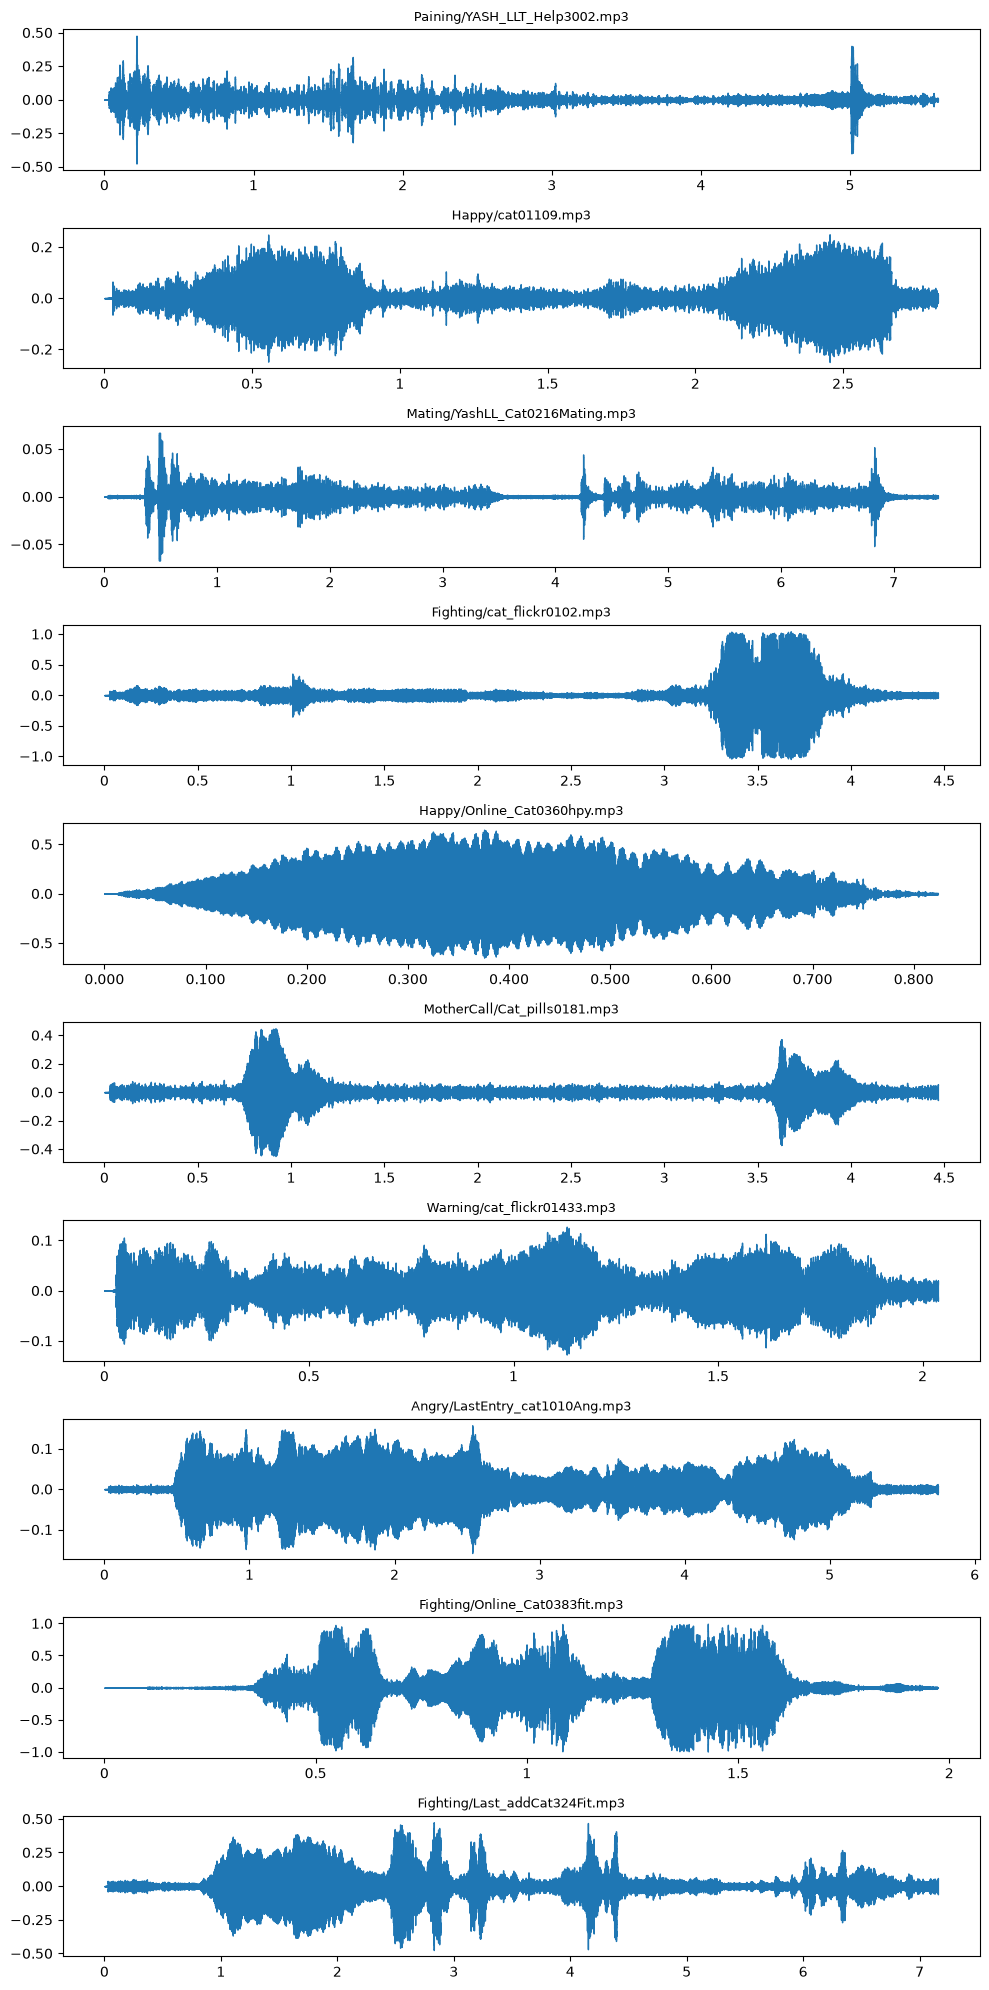

In [15]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import librosa.display

DATA_DIR = Path("/home/cjk/Dev/04_Lewagon/cats/260908 CatSound_originals_only/CatSound_originals")

all_files = list(DATA_DIR.rglob("*.mp3"))
sample_files = random.sample(all_files, 10)

fig, axes = plt.subplots(10, 1, figsize=(10, 20))
for ax, file_path in zip(axes, sample_files):
    y, sr = librosa.load(file_path, sr=32000, mono=True)
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(f"{file_path.parent.name}/{file_path.name}", fontsize=9)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()
